# WS2 Results Overview — Gemma 3 4B IT

Analyzes results from Exp 2.1 (EVA JS divergence), Exp 2.2 (EVA decoding), Exp 2.4 (Chain-of-Embedding / VIP / TVI), and Exp 2.5 (SAE Convergence), and concept analysis (SAE training data vs. benchmark coverage).

**Model:** `google/gemma-3-4b-it`  
**Benchmarks:** VLMs Are Biased (VAB), ViLP, VLind-Bench  
**Goal:** Identify the WS3 target layer from the intersection of VIP and SAE convergence.

In [95]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
RESULTS = Path('../results')
MODEL   = 'google_gemma-3-4b-it'

DATASETS = ['vlms_are_biased', 'vilp', 'vlind']
LABELS   = {'vlms_are_biased': 'VAB', 'vilp': 'ViLP', 'vlind': 'VLind'}
COLORS   = {'vlms_are_biased': 'steelblue', 'vilp': 'coral', 'vlind': 'seagreen'}

## 1. Chain-of-Embedding: VIP and TVI

In [96]:
coe_summaries, coe_distances, coe_tvi = {}, {}, {}
for ds in DATASETS:
    base = RESULTS / 'chain_of_embedding' / MODEL / ds
    with open(base / 'summary.json') as f:
        coe_summaries[ds] = json.load(f)
    coe_distances[ds] = np.load(base / 'distances.npz', allow_pickle=True)
    coe_tvi[ds]       = np.load(base / 'tvi.npz',       allow_pickle=True)

print(f"{'Dataset':<20} {'VIP median':>10} {'VIP mean':>10} {'TVI mean':>10} {'n_dvt':>7} {'n_dt':>7}")
print('-' * 68)
for ds in DATASETS:
    s = coe_summaries[ds]
    print(f"{LABELS[ds]:<20} {s['vip_median']:>10} {s['vip_mean']:>10.1f} "
          f"{s['mean']:>10.5f} {s.get('n_dvt', 'N/A'):>7} {s.get('n_dt', 'N/A'):>7}")

Dataset              VIP median   VIP mean   TVI mean   n_dvt    n_dt
--------------------------------------------------------------------
VAB                          16       16.1    0.00020     129    2655
ViLP                         15       15.3    0.00024      62     238
VLind                        15       14.9    0.00009      29     273


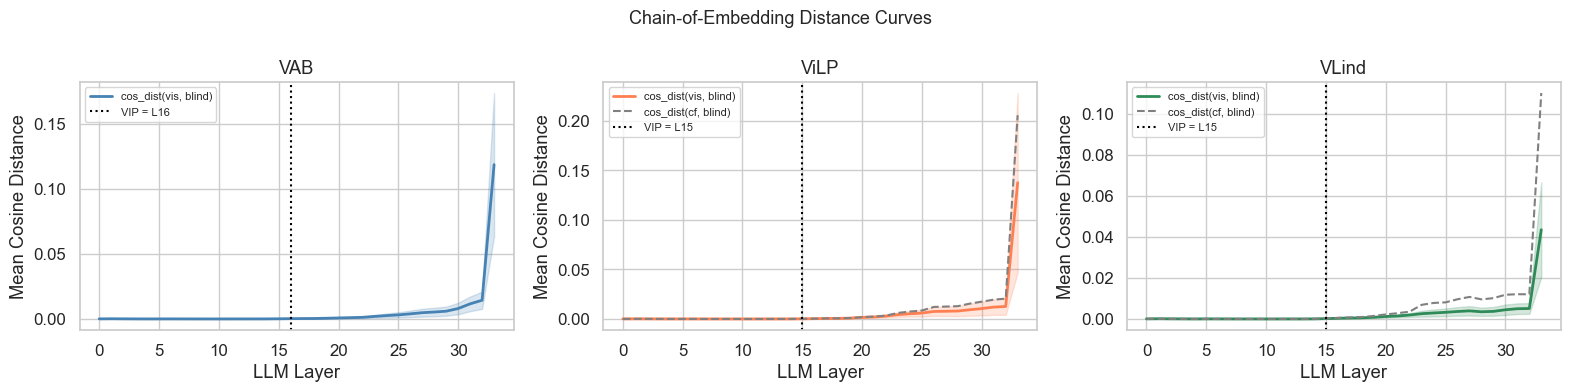

In [97]:
# Mean distance curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ds in zip(axes, DATASETS):
    d_vis = coe_distances[ds]['d_vis']
    mean_vis, std_vis = d_vis.mean(0), d_vis.std(0)
    layers = np.arange(len(mean_vis))
    vip = coe_summaries[ds]['vip_median']

    ax.plot(layers, mean_vis, color=COLORS[ds], lw=2, label='cos_dist(vis, blind)')
    ax.fill_between(layers, mean_vis - std_vis, mean_vis + std_vis, alpha=0.2, color=COLORS[ds])
    if coe_distances[ds]['d_cf'].ndim == 2 and coe_distances[ds]['d_cf'].shape[0] > 0:
        ax.plot(layers, coe_distances[ds]['d_cf'].mean(0), color='gray', lw=1.5,
                linestyle='--', label='cos_dist(cf, blind)')
    ax.axvline(vip, color='black', lw=1.5, linestyle=':', label=f'VIP = L{vip}')
    ax.set_title(LABELS[ds]); ax.set_xlabel('LLM Layer'); ax.set_ylabel('Mean Cosine Distance')
    ax.legend(fontsize=8)

fig.suptitle('Chain-of-Embedding Distance Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / 'chain_of_embedding' / 'vip_overview.png', dpi=150, bbox_inches='tight')
plt.show()

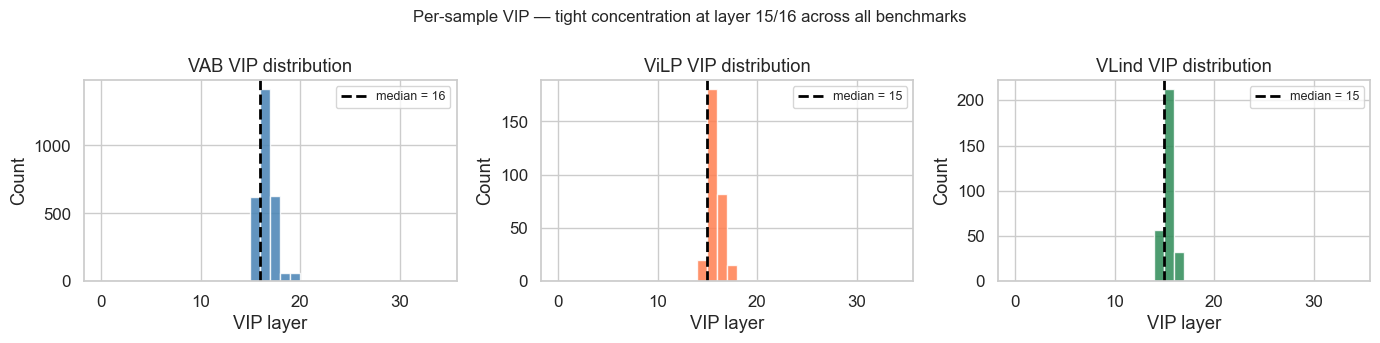

In [98]:
# VIP distribution histograms — one bin per layer
# Shows that almost every sample crosses the threshold at the same layer
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, ds in zip(axes, DATASETS):
    vips = coe_tvi[ds]['vip']
    ax.hist(vips, bins=range(0, 35), color=COLORS[ds], edgecolor='white', alpha=0.85)
    ax.axvline(int(np.median(vips)), color='black', lw=2, linestyle='--',
               label=f'median = {int(np.median(vips))}')
    ax.set_title(f'{LABELS[ds]} VIP distribution')
    ax.set_xlabel('VIP layer'); ax.set_ylabel('Count'); ax.legend(fontsize=9)

plt.suptitle('Per-sample VIP — tight concentration at layer 15/16 across all benchmarks', fontsize=12)
plt.tight_layout()
plt.show()

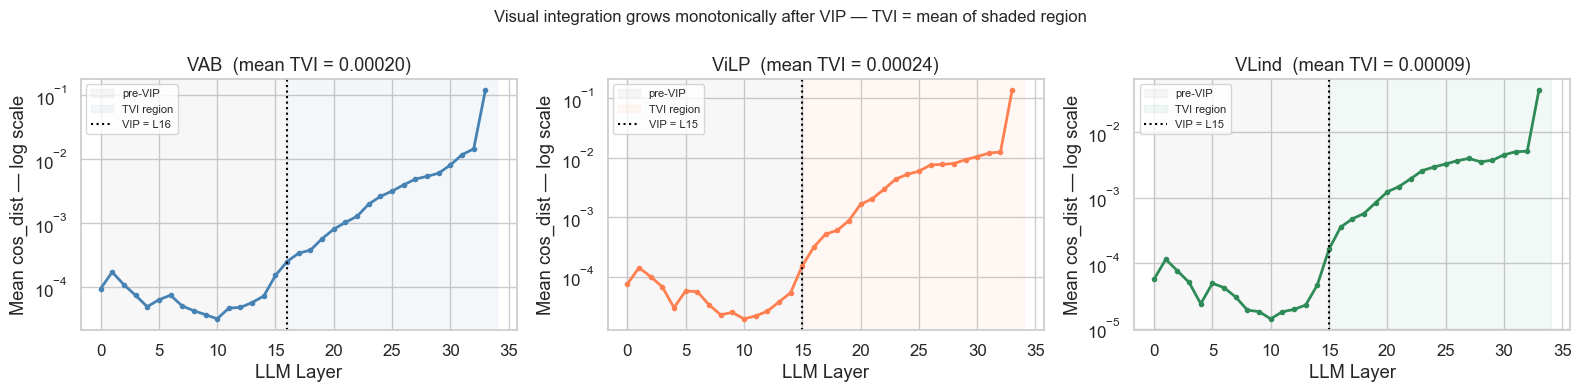

In [99]:
# Log-scale distance curves with VIP and TVI region shaded
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, ds in zip(axes, DATASETS):
    d_vis    = coe_distances[ds]['d_vis'].mean(0)
    layers   = np.arange(len(d_vis))
    vip      = coe_summaries[ds]['vip_median']
    tvi_mean = coe_summaries[ds]['mean']

    ax.axvspan(0, vip,            alpha=0.06, color='gray',       label='pre-VIP')
    ax.axvspan(vip, len(layers),  alpha=0.06, color=COLORS[ds],   label='TVI region')
    ax.semilogy(layers, np.maximum(d_vis, 1e-7), 'o-', color=COLORS[ds], lw=2, ms=3)
    ax.axvline(vip, color='black', lw=1.5, linestyle=':', label=f'VIP = L{vip}')
    ax.set_title(f'{LABELS[ds]}  (mean TVI = {tvi_mean:.5f})')
    ax.set_xlabel('LLM Layer'); ax.set_ylabel('Mean cos_dist — log scale')
    ax.legend(fontsize=8)

plt.suptitle('Visual integration grows monotonically after VIP — TVI = mean of shaded region', fontsize=12)
plt.tight_layout()
plt.show()

In [100]:
# D_VT vs D_T summary table
print('D_VT = vision-dependent: answer changed with image AND correct')
print('D_T  = text-dependent:   answer same regardless of image\n')
print(f"{'Dataset':<10} {'TVI D_VT':>10} {'TVI D_T':>10} {'n_dvt':>7} {'% visual':>10}")
print('-' * 52)
for ds in DATASETS:
    s = coe_summaries[ds]
    n_dvt = s.get('n_dvt', 0); n_dt = s.get('n_dt', 0)
    pct = 100 * n_dvt / (n_dvt + n_dt) if (n_dvt + n_dt) > 0 else 0
    print(f"{LABELS[ds]:<10} {s.get('tvi_mean_dvt', float('nan')):>10.5f} "
          f"{s.get('tvi_mean_dt', float('nan')):>10.5f} {n_dvt:>7} {pct:>9.1f}%")
print('\nNOTE: VAB n_dvt=0 may be a bug (single-token decoding) — rerun pending.')

D_VT = vision-dependent: answer changed with image AND correct
D_T  = text-dependent:   answer same regardless of image

Dataset      TVI D_VT    TVI D_T   n_dvt   % visual
----------------------------------------------------
VAB           0.00020    0.00020     129       4.6%
ViLP          0.00035    0.00022      62      20.7%
VLind         0.00016    0.00009      29       9.6%

NOTE: VAB n_dvt=0 may be a bug (single-token decoding) — rerun pending.


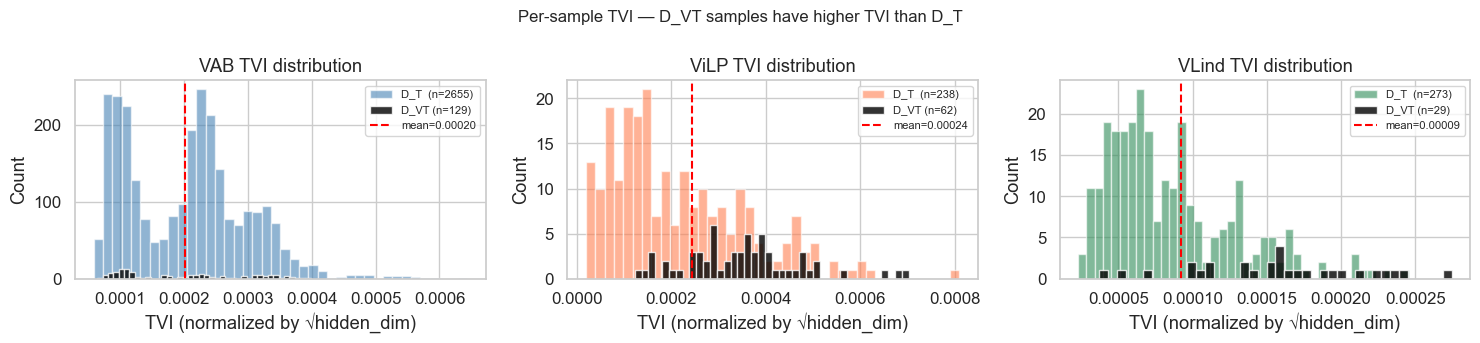

In [101]:
# TVI per-sample distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, ds in zip(axes, DATASETS):
    tvi     = coe_tvi[ds]['tvi']
    vis_dep = coe_tvi[ds]['is_vision_dependent'].astype(bool)
    ax.hist(tvi[~vis_dep], bins=40, color=COLORS[ds], alpha=0.6,
            label=f'D_T  (n={(~vis_dep).sum()})')
    if vis_dep.any():
        ax.hist(tvi[vis_dep], bins=40, color='black', alpha=0.8,
                label=f'D_VT (n={vis_dep.sum()})')
    ax.axvline(tvi.mean(), color='red', lw=1.5, linestyle='--', label=f'mean={tvi.mean():.5f}')
    ax.set_title(f'{LABELS[ds]} TVI distribution')
    ax.set_xlabel('TVI (normalized by √hidden_dim)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

plt.suptitle('Per-sample TVI — D_VT samples have higher TVI than D_T', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/92/vn97p82j2sq0hx9c9xlrq70w0000gn/T/ipykernel_9078/2550522995.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.4,
/var/folders/92/vn97p82j2sq0hx9c9xlrq70w0000gn/T/ipykernel_9078/2550522995.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.4,
/var/folders/92/vn97p82j2sq0hx9c9xlrq70w0000gn/T/ipykernel_9078/2550522995.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.4,


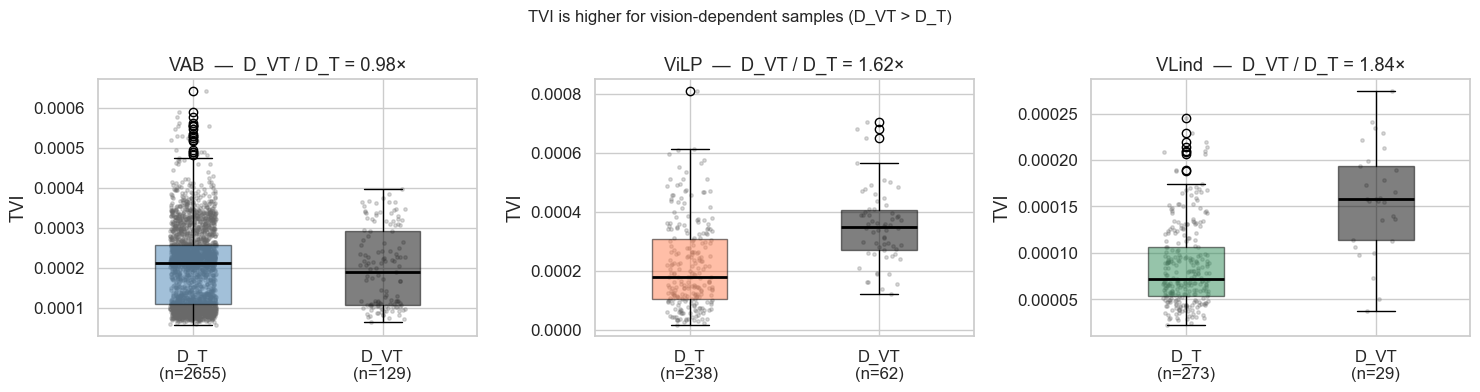

In [102]:
# D_VT vs D_T box plot
datasets_with_dvt = [ds for ds in DATASETS if coe_tvi[ds]['is_vision_dependent'].sum() > 0]
if not datasets_with_dvt:
    print('No datasets with D_VT samples yet — rerun chain-of-embedding with fix applied.')
else:
    fig, axes = plt.subplots(1, len(datasets_with_dvt), figsize=(5 * len(datasets_with_dvt), 4))
    if len(datasets_with_dvt) == 1: axes = [axes]
    rng = np.random.default_rng(42)
    for ax, ds in zip(axes, datasets_with_dvt):
        tvi     = coe_tvi[ds]['tvi']
        vis_dep = coe_tvi[ds]['is_vision_dependent'].astype(bool)
        groups  = [tvi[~vis_dep], tvi[vis_dep]]
        labels  = [f'D_T\n(n={(~vis_dep).sum()})', f'D_VT\n(n={vis_dep.sum()})']
        bp = ax.boxplot(groups, labels=labels, patch_artist=True, widths=0.4,
                        medianprops=dict(color='black', lw=2))
        bp['boxes'][0].set_facecolor(COLORS[ds]); bp['boxes'][0].set_alpha(0.5)
        bp['boxes'][1].set_facecolor('black');    bp['boxes'][1].set_alpha(0.5)
        for i, grp in enumerate(groups, start=1):
            ax.scatter(np.full(len(grp), i) + rng.uniform(-0.12, 0.12, len(grp)),
                       grp, alpha=0.25, s=6, color='dimgray')
        s = coe_summaries[ds]
        ratio = s['tvi_mean_dvt'] / s['tvi_mean_dt'] if s.get('tvi_mean_dt') else float('nan')
        ax.set_title(f"{LABELS[ds]}  —  D_VT / D_T = {ratio:.2f}×"); ax.set_ylabel('TVI')
    plt.suptitle('TVI is higher for vision-dependent samples (D_VT > D_T)', fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS / 'chain_of_embedding' / 'tvi_dvt_vs_dt.png', dpi=150, bbox_inches='tight')
    plt.show()

### 1b. vab_pairs — Three-Condition Analysis

vab_pairs has paired original + counterfactual images (subtle visual edits, e.g. added leg).
This gives three conditions:
- **d_vis** = cos_dist(original, blind) — how much does the image shift the representation?
- **d_cf** = cos_dist(counterfactual, blind) — same for the counterfactual image
- **d_disc** = cos_dist(original, counterfactual) — can the model discriminate the two images?

If the model ignores visual details, d_disc stays near zero even after VIP.

In [103]:
vp_base = RESULTS / 'chain_of_embedding' / MODEL / 'vab_pairs'
with open(vp_base / 'summary.json') as f:
    vp_summary = json.load(f)
vp_dist = np.load(vp_base / 'distances.npz', allow_pickle=True)
vp_tvi  = np.load(vp_base / 'tvi.npz',       allow_pickle=True)

print(f"n={vp_summary['n_samples']}  VIP median={vp_summary['vip_median']}  "
      f"mean TVI={vp_summary['mean']:.5f}")
print(f"n_dvt={vp_summary['n_dvt']}  n_dt={vp_summary['n_dt']}  "
      f"({100*vp_summary['n_dvt']/(vp_summary['n_dvt']+vp_summary['n_dt']):.1f}% visual)")

n=528  VIP median=17  mean TVI=0.00023
n_dvt=29  n_dt=499  (5.5% visual)


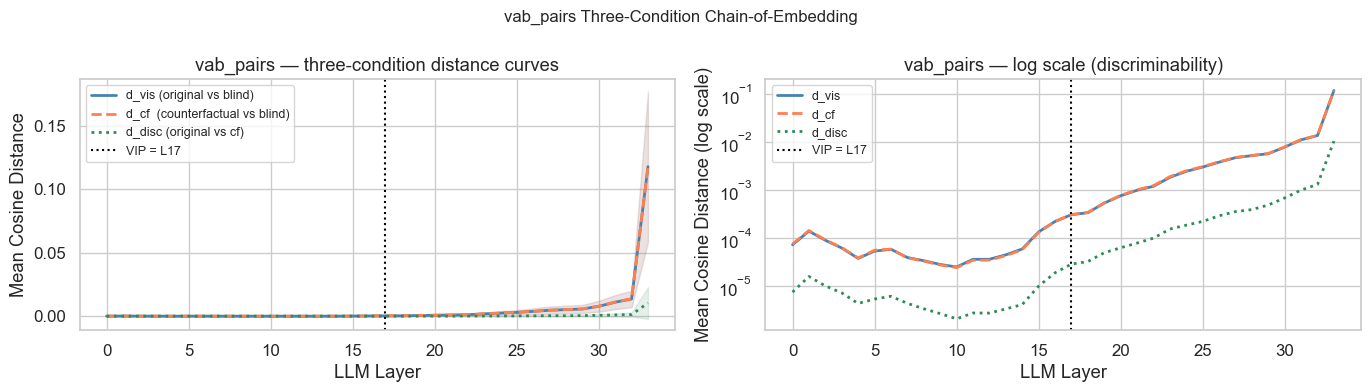

In [104]:
# Three-condition distance curves
d_vis  = vp_dist['d_vis']
d_cf   = vp_dist['d_cf']
d_disc = vp_dist['d_disc']
layers = np.arange(d_vis.shape[1])
vip    = vp_summary['vip_median']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1 — mean distance curves for all three conditions
ax = axes[0]
for arr, label, color, ls in [
    (d_vis,  'd_vis (original vs blind)',       'steelblue', '-'),
    (d_cf,   'd_cf  (counterfactual vs blind)',  'coral',     '--'),
    (d_disc, 'd_disc (original vs cf)',          'seagreen',  ':'),
]:
    m, s = arr.mean(0), arr.std(0)
    ax.plot(layers, m, color=color, lw=2, linestyle=ls, label=label)
    ax.fill_between(layers, m - s, m + s, alpha=0.12, color=color)
ax.axvline(vip, color='black', lw=1.5, linestyle=':', label=f'VIP = L{vip}')
ax.set_xlabel('LLM Layer'); ax.set_ylabel('Mean Cosine Distance')
ax.set_title('vab_pairs — three-condition distance curves')
ax.legend(fontsize=9)

# Panel 2 — log scale to show discriminability
ax = axes[1]
for arr, label, color, ls in [
    (d_vis,  'd_vis', 'steelblue', '-'),
    (d_cf,   'd_cf',  'coral',     '--'),
    (d_disc, 'd_disc','seagreen',  ':'),
]:
    ax.semilogy(layers, np.maximum(arr.mean(0), 1e-7), color=color, lw=2, linestyle=ls, label=label)
ax.axvline(vip, color='black', lw=1.5, linestyle=':', label=f'VIP = L{vip}')
ax.set_xlabel('LLM Layer'); ax.set_ylabel('Mean Cosine Distance (log scale)')
ax.set_title('vab_pairs — log scale (discriminability)')
ax.legend(fontsize=9)

plt.suptitle('vab_pairs Three-Condition Chain-of-Embedding', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS / 'chain_of_embedding' / 'vab_pairs_curves.png', dpi=150, bbox_inches='tight')
plt.show()

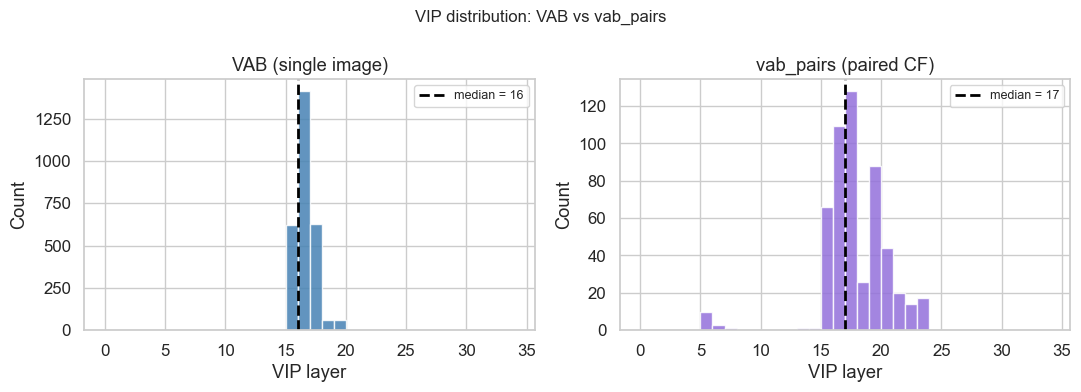

Dataset              VIP median   TVI mean   n_dvt    n_dt   % visual
-----------------------------------------------------------------
VAB                          16    0.00020     129    2655       4.6%
vab_pairs                    17    0.00023      29     499       5.5%


In [105]:
# VIP comparison: VAB (no pairs) vs vab_pairs
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (ds, label, color) in zip(axes, [
    ('vlms_are_biased', 'VAB (single image)', COLORS['vlms_are_biased']),
    ('vab_pairs',       'vab_pairs (paired CF)', 'mediumpurple'),
]):
    if ds == 'vab_pairs':
        vips = vp_tvi['vip']
        med  = int(np.median(vips))
    else:
        vips = coe_tvi[ds]['vip']
        med  = int(np.median(vips))
    ax.hist(vips, bins=range(0, 35), color=color, edgecolor='white', alpha=0.85)
    ax.axvline(med, color='black', lw=2, linestyle='--', label=f'median = {med}')
    ax.set_title(label); ax.set_xlabel('VIP layer'); ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('VIP distribution: VAB vs vab_pairs', fontsize=12)
plt.tight_layout()
plt.show()

# D_VT / D_T comparison table
print(f"{'Dataset':<20} {'VIP median':>10} {'TVI mean':>10} {'n_dvt':>7} {'n_dt':>7} {'% visual':>10}")
print('-' * 65)
for ds, label in [('vlms_are_biased', 'VAB'), ('vab_pairs', 'vab_pairs')]:
    if ds == 'vab_pairs':
        s = vp_summary
    else:
        s = coe_summaries[ds]
    pct = 100 * s['n_dvt'] / (s['n_dvt'] + s['n_dt']) if (s['n_dvt'] + s['n_dt']) > 0 else 0
    print(f"{label:<20} {s['vip_median']:>10} {s['mean']:>10.5f} "
          f"{s['n_dvt']:>7} {s['n_dt']:>7} {pct:>9.1f}%")

## 2. EVA Decoding

**EVA** = **E**xtracting **V**isual f**A**cts from intermediate layers.

At each layer, compute JS divergence between multimodal and text-only next-token distributions. The peak layer is where visual information most strongly influences the prediction. EVA then injects this visual correction into the final logits:

```
p_EVA = softmax(log p_vis + α × (log p_vis − log p_blind))
```

**Exp 2.1:** Find peak layer on VQAv2.  
**Exp 2.2:** Apply EVA correction at that layer on the bias benchmarks.

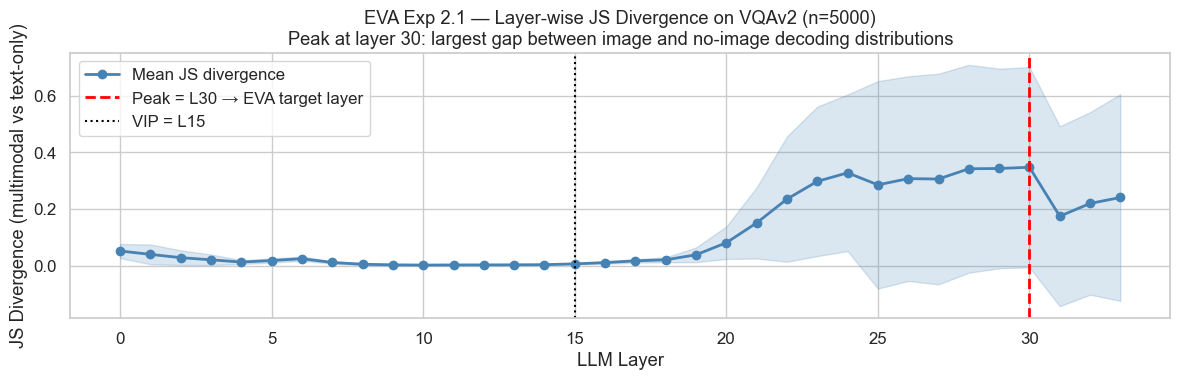

Peak JS divergence: layer 30 / 34 (88% depth)
VIP: layer 15 / 34 (44% depth)
Gap: 15 layers between visual integration onset (VIP) and peak information divergence (EVA)


In [106]:
# Exp 2.1 — JS divergence per layer on VQAv2
eva_js = np.load(RESULTS / 'eva' / 'vqav2' / 'js_per_layer.npz', allow_pickle=True)
with open(RESULTS / 'eva' / 'vqav2' / 'summary.json') as f:
    eva_summary = json.load(f)

mean_js = eva_js['mean_js']
std_js  = eva_js['std_js']
layers  = np.arange(len(mean_js))
peak    = eva_summary['peak_layer']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(layers, mean_js, 'o-', color='steelblue', lw=2, label='Mean JS divergence')
ax.fill_between(layers, mean_js - std_js, mean_js + std_js, alpha=0.2, color='steelblue')
ax.axvline(peak, color='red', lw=2, linestyle='--', label=f'Peak = L{peak} → EVA target layer')
ax.axvline(15, color='black', lw=1.5, linestyle=':', label='VIP = L15')
ax.set_xlabel('LLM Layer')
ax.set_ylabel('JS Divergence (multimodal vs text-only)')
ax.set_title(f'EVA Exp 2.1 — Layer-wise JS Divergence on VQAv2 (n=5000)\n'
             f'Peak at layer {peak}: largest gap between image and no-image decoding distributions')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'eva' / 'vqav2' / 'js_divergence_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak JS divergence: layer {peak} / {len(mean_js)} ({100*peak/len(mean_js):.0f}% depth)')
print(f'VIP: layer 15 / {len(mean_js)} ({100*15/len(mean_js):.0f}% depth)')
print(f'Gap: {peak - 15} layers between visual integration onset (VIP) and peak information divergence (EVA)')

In [107]:
# Exp 2.2 — EVA decoding accuracy sweep
eva_sweeps = {}
for ds in DATASETS:
    sweep_path = RESULTS / 'eva_decoding' / MODEL / ds / 'layer_30' / 'sweep_summary.json'
    if sweep_path.exists():
        with open(sweep_path) as f:
            eva_sweeps[ds] = json.load(f)
    else:
        partial = []
        for alpha in ['0.00', '0.50', '1.00', '2.00']:
            p = RESULTS / 'eva_decoding' / MODEL / ds / 'layer_30' / f'alpha_{alpha}' / 'summary.json'
            if p.exists():
                with open(p) as f: partial.append(json.load(f))
        if partial: eva_sweeps[ds] = partial

for ds, sweep in eva_sweeps.items():
    print(f'\n{LABELS[ds]}')
    print(f"  {'alpha':>6} {'vanilla':>9} {'eva':>9} {'delta':>9}")
    for r in sweep:
        print(f"  {r['alpha']:>6.1f} {r['vanilla_accuracy']:>9.3f} {r['eva_accuracy']:>9.3f} {r['accuracy_delta']:>+9.3f}")


VAB
   alpha   vanilla       eva     delta
     0.0     0.176     0.177    +0.001
     0.5     0.176     0.172    -0.004
     1.0     0.176     0.163    -0.013

ViLP
   alpha   vanilla       eva     delta
     0.0     0.713     0.713    +0.000
     0.5     0.713     0.683    -0.030
     1.0     0.713     0.667    -0.047
     2.0     0.713     0.613    -0.100

VLind
   alpha   vanilla       eva     delta
     0.0     0.103     0.103    +0.000
     0.5     0.103     0.119    +0.017
     1.0     0.103     0.132    +0.030
     2.0     0.103     0.142    +0.040


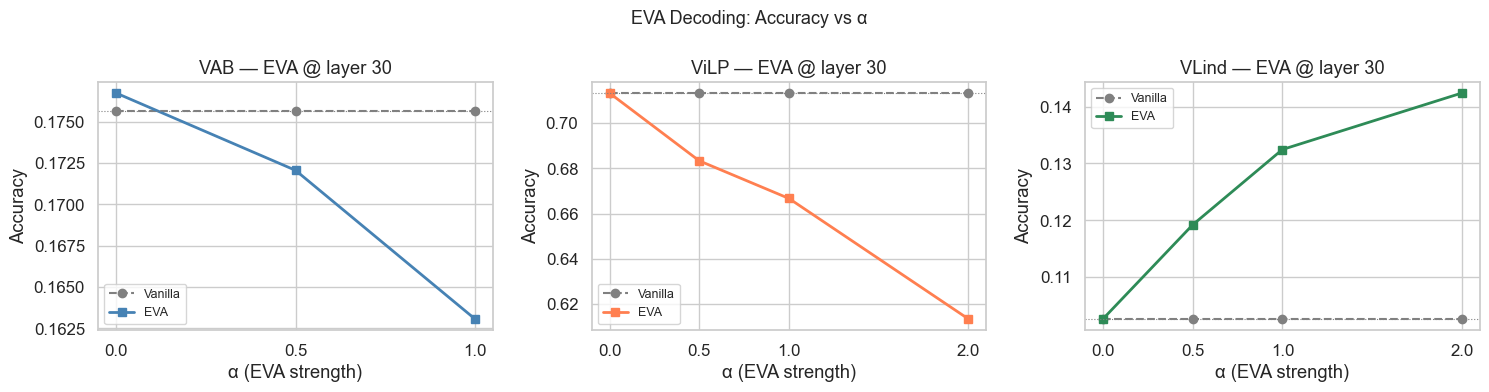

In [108]:
fig, axes = plt.subplots(1, len(eva_sweeps), figsize=(5 * len(eva_sweeps), 4), sharey=False)
if len(eva_sweeps) == 1: axes = [axes]
for ax, (ds, sweep) in zip(axes, eva_sweeps.items()):
    alphas  = [r['alpha'] for r in sweep]
    vanilla = [r['vanilla_accuracy'] for r in sweep]
    eva_acc = [r['eva_accuracy'] for r in sweep]
    ax.plot(alphas, vanilla, 'o--', color='gray', label='Vanilla', lw=1.5)
    ax.plot(alphas, eva_acc, 's-',  color=COLORS[ds], label='EVA', lw=2)
    ax.axhline(vanilla[0], color='gray', lw=0.8, linestyle=':')
    ax.set_title(f'{LABELS[ds]} — EVA @ layer {peak}')
    ax.set_xlabel('α (EVA strength)'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9); ax.set_xticks(alphas)
plt.suptitle('EVA Decoding: Accuracy vs α', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / 'eva_decoding' / 'eva_accuracy_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [109]:
# VAB per-topic breakdown
vab_path = RESULTS / 'eva_decoding' / MODEL / 'vlms_are_biased' / 'layer_30' / 'alpha_0.00' / 'summary.json'
if vab_path.exists():
    with open(vab_path) as f: vab_a0 = json.load(f)
    print('VAB per-topic accuracy (vanilla, alpha=0.0):')
    print(f"  {'Topic':<20} {'Accuracy':>9} {'n':>6}")
    print('  ' + '-' * 40)
    for topic, stats in vab_a0['accuracy_by_topic'].items():
        print(f"  {topic:<20} {stats['vanilla']:>9.3f} {stats['n']:>6}")

VAB per-topic accuracy (vanilla, alpha=0.0):
  Topic                 Accuracy      n
  ----------------------------------------
  Optical Illusion         0.516    792
  Game Boards              0.024    168
  Patterned Grid           0.012    336
  Chess Pieces             0.000    288
  Logos                    0.072    414
  Flags                    0.175    240
  Animals                  0.000    546


### 2b. vab_pairs — EVA JS Divergence

vab_pairs has two EVA JS divergence modes:
- **standard**: JS(multimodal ‖ text-only) — same as VQAv2 analysis, measures how much the image shifts the prediction
- **cf_disc**: JS(original ‖ counterfactual) — how much the subtle visual edit shifts the model's distribution

cf_disc is the key new signal: if the model is ignoring fine-grained visual details,
this stays near zero even though standard JS divergence may be non-zero.

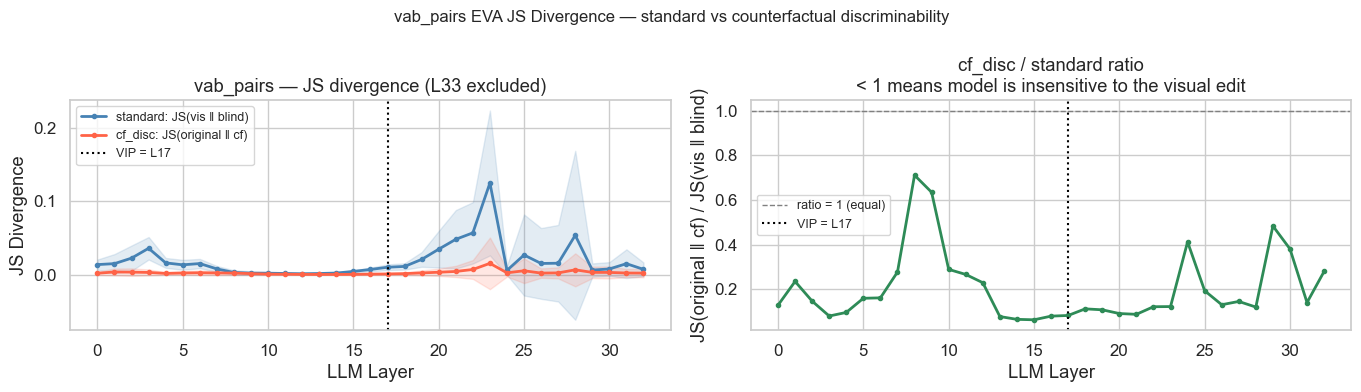

Standard peak layer (excl. L33): 23
cf_disc peak layer  (excl. L33): 23
Mean cf_disc/standard ratio: 0.203


In [110]:
vp_eva_std = np.load(RESULTS / 'eva' / 'vab_pairs' / 'js_per_layer.npz', allow_pickle=True)
vp_eva_cf  = np.load(RESULTS / 'eva' / 'vab_pairs' / 'js_cf_disc.npz',   allow_pickle=True)
with open(RESULTS / 'eva' / 'vab_pairs' / 'summary.json') as f:
    vp_eva_std_summary = json.load(f)
with open(RESULTS / 'eva' / 'vab_pairs' / 'summary_cf_disc.json') as f:
    vp_eva_cf_summary  = json.load(f)

layers_eva = np.arange(len(vp_eva_std['mean_js']))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1 — overlay both curves
ax = axes[0]
for js_data, label, color in [
    (vp_eva_std, 'standard: JS(vis ‖ blind)',        'steelblue'),
    (vp_eva_cf,  'cf_disc: JS(original ‖ cf)',       'tomato'),
]:
    m, s = js_data['mean_js'], js_data['std_js']
    # exclude last layer (L33 outlier)
    ax.plot(layers_eva[:-1], m[:-1], 'o-', color=color, lw=2, ms=3, label=label)
    ax.fill_between(layers_eva[:-1], (m-s)[:-1], (m+s)[:-1], alpha=0.15, color=color)
ax.axvline(vp_summary['vip_median'], color='black', lw=1.5, linestyle=':',
           label=f"VIP = L{vp_summary['vip_median']}")
ax.set_xlabel('LLM Layer'); ax.set_ylabel('JS Divergence')
ax.set_title('vab_pairs — JS divergence (L33 excluded)')
ax.legend(fontsize=9)

# Panel 2 — ratio: how much does the CF shift relative to image vs blind?
ax = axes[1]
std_m = vp_eva_std['mean_js'][:-1]
cf_m  = vp_eva_cf['mean_js'][:-1]
ratio = cf_m / (std_m + 1e-10)
ax.plot(layers_eva[:-1], ratio, 'o-', color='seagreen', lw=2, ms=3)
ax.axhline(1.0, color='gray', lw=1, linestyle='--', label='ratio = 1 (equal)')
ax.axvline(vp_summary['vip_median'], color='black', lw=1.5, linestyle=':',
           label=f"VIP = L{vp_summary['vip_median']}")
ax.set_xlabel('LLM Layer')
ax.set_ylabel('JS(original ‖ cf) / JS(vis ‖ blind)')
ax.set_title('cf_disc / standard ratio\n< 1 means model is insensitive to the visual edit')
ax.legend(fontsize=9)

plt.suptitle('vab_pairs EVA JS Divergence — standard vs counterfactual discriminability', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS / 'eva' / 'vab_pairs_js_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Standard peak layer (excl. L33): {np.argmax(vp_eva_std['mean_js'][:-1])}")
print(f"cf_disc peak layer  (excl. L33): {np.argmax(vp_eva_cf['mean_js'][:-1])}")
print(f"Mean cf_disc/standard ratio: {ratio.mean():.3f}")

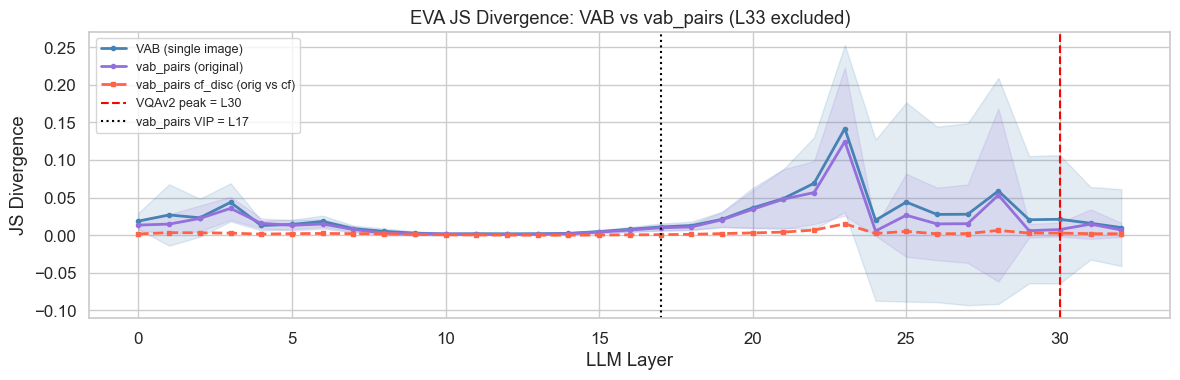

In [111]:
# Compare standard JS divergence: VAB vs vab_pairs
vab_eva = np.load(RESULTS / 'eva' / 'vlms_are_biased' / 'js_per_layer.npz', allow_pickle=True)

fig, ax = plt.subplots(figsize=(12, 4))
for js_data, label, color in [
    (vab_eva,    'VAB (single image)',    COLORS['vlms_are_biased']),
    (vp_eva_std, 'vab_pairs (original)', 'mediumpurple'),
]:
    m, s = js_data['mean_js'][:-1], js_data['std_js'][:-1]
    ax.plot(layers_eva[:-1], m, 'o-', color=color, lw=2, ms=3, label=label)
    ax.fill_between(layers_eva[:-1], m - s, m + s, alpha=0.15, color=color)
ax.plot(layers_eva[:-1], vp_eva_cf['mean_js'][:-1], 's--', color='tomato',
        lw=2, ms=3, label='vab_pairs cf_disc (orig vs cf)')
ax.axvline(peak, color='red', lw=1.5, linestyle='--', label=f'VQAv2 peak = L{peak}')
ax.axvline(vp_summary['vip_median'], color='black', lw=1.5, linestyle=':',
           label=f"vab_pairs VIP = L{vp_summary['vip_median']}")
ax.set_xlabel('LLM Layer'); ax.set_ylabel('JS Divergence')
ax.set_title('EVA JS Divergence: VAB vs vab_pairs (L33 excluded)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. SAE Convergence

In [112]:
sae_dir = RESULTS / 'sae_convergence_big'
with open(sae_dir / 'summary.json') as f:
    sae_summary = json.load(f)

layers  = np.array(sae_summary['probed_layers'])
vis_mse = np.array(sae_summary['visual_normalized_mse'])
txt_mse = np.array(sae_summary['text_normalized_mse'])
stable_min_layer = layers[:-1][np.argmin(vis_mse[:-1])]

print(f'Layer 33 visual MSE: {vis_mse[-1]:.1f}  (outlier — excluded from plot)')
print(f'Reported convergence_layer: {sae_summary["convergence_layer"]} (first 3-consecutive below threshold)')
print(f'Minimum visual MSE layer (excl. L33): {stable_min_layer}')

Layer 33 visual MSE: 401.1  (outlier — excluded from plot)
Reported convergence_layer: 3 (first 3-consecutive below threshold)
Minimum visual MSE layer (excl. L33): 14


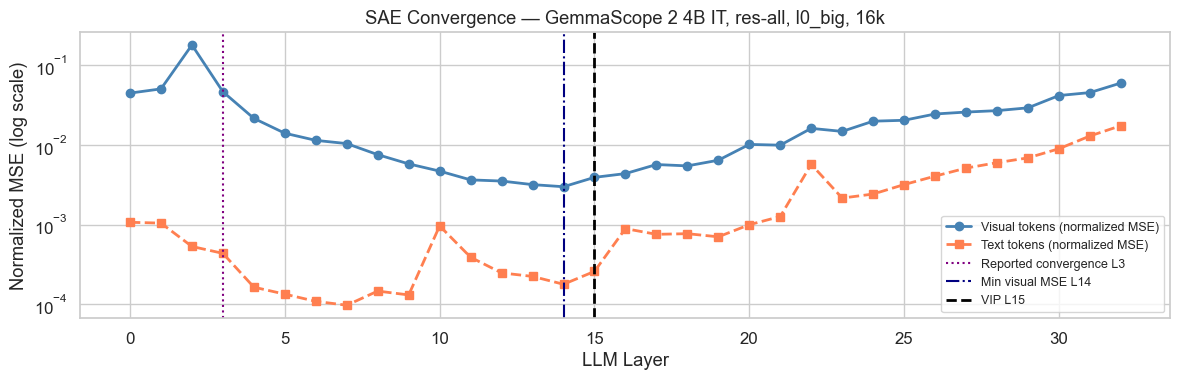

In [113]:
mask = layers < 33
l, vm, tm = layers[mask], vis_mse[mask], txt_mse[mask]
vip_ref = 15

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(l, vm, 'o-',  color='steelblue', lw=2, label='Visual tokens (normalized MSE)')
ax.semilogy(l, tm, 's--', color='coral',     lw=2, label='Text tokens (normalized MSE)')
ax.axvline(sae_summary['convergence_layer'], color='purple', lw=1.5, linestyle=':',
           label=f'Reported convergence L{sae_summary["convergence_layer"]}')
ax.axvline(stable_min_layer, color='navy', lw=1.5, linestyle='-.',
           label=f'Min visual MSE L{stable_min_layer}')
ax.axvline(vip_ref, color='black', lw=2, linestyle='--', label=f'VIP L{vip_ref}')
ax.set_xlabel('LLM Layer'); ax.set_ylabel('Normalized MSE (log scale)')
ax.set_title('SAE Convergence — GemmaScope 2 4B IT, res-all, l0_big, 16k')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(sae_dir / 'convergence_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [114]:
print(f"{'Layer':>6} {'Vis MSE':>12} {'Txt MSE':>12} {'Ratio v/t':>12}")
print('-' * 46)
for i, layer in enumerate(layers):
    if layer > 25: continue
    ratio = vis_mse[i] / (txt_mse[i] + 1e-10)
    marker = '  <-- min vis MSE' if layer == stable_min_layer else ''
    print(f"{layer:>6} {vis_mse[i]:>12.5f} {txt_mse[i]:>12.5f} {ratio:>12.1f}{marker}")

 Layer      Vis MSE      Txt MSE    Ratio v/t
----------------------------------------------
     0      0.04484      0.00107         42.1
     1      0.05067      0.00104         48.7
     2      0.18072      0.00053        341.3
     3      0.04662      0.00043        107.5
     4      0.02158      0.00016        132.4
     5      0.01404      0.00013        105.4
     6      0.01142      0.00011        105.6
     7      0.01040      0.00010        107.6
     8      0.00755      0.00015         51.9
     9      0.00578      0.00013         44.4
    10      0.00469      0.00096          4.9
    11      0.00364      0.00039          9.4
    12      0.00352      0.00025         14.3
    13      0.00317      0.00022         14.3
    14      0.00298      0.00018         16.8  <-- min vis MSE
    15      0.00391      0.00026         15.2
    16      0.00436      0.00089          4.9
    17      0.00567      0.00075          7.5
    18      0.00545      0.00077          7.1
    19      0.00

## 3b. Exp 3.1 — Contrastive SAE Feature Search

For 5000 VQAv2 samples at layer 16, extract hidden states under two conditions:
- **Condition B (vis):** original image present
- **Condition A (blind):** pixel values zeroed

Run both through the GemmaScope 2 4B IT SAE (16k width, l0=big). For each latent j:
- `f_vis_j` = fraction of samples where latent j fires with image
- `f_blind_j` = fraction without image
- `s_visual_j = f_vis_j - f_blind_j` (visual reliance score)

**Headline:** Top visual latent (#9869) fires on 32.1% of image samples but only 0.3% of blind samples.
The visual-prior score asymmetry is **21x** (0.318 vs 0.015) — visual reliance latents are far crisper than language prior latents on VQAv2.

In [124]:
fs_dir = RESULTS / 'feature_search' / MODEL / 'vqav2' / 'layer_16'
with open(fs_dir / 'summary.json') as f:
    fs_summary = json.load(f)
with open(fs_dir / 'top_features.json') as f:
    fs_features = json.load(f)
fs_scores = np.load(fs_dir / 'scores.npz', allow_pickle=True)

top_visual = fs_features['top_visual']
top_prior  = fs_features['top_prior']
f_vis_all   = fs_scores['f_vis']
f_blind_all = fs_scores['f_blind']
s_vis_all   = fs_scores['s_visual']

print(f"Total latents: {fs_summary['n_sae_latents']:,}  After noise filter: {fs_summary['n_latents_after_noise_filter']:,}")
print(f"Top visual latent: {fs_summary['top_visual_latent']}  s={fs_summary['top_visual_score']:.3f}")
print(f"Top prior  latent: {fs_summary['top_prior_latent']}  s={fs_summary['top_prior_score']:.4f}")
print(f"Visual/prior ratio: {fs_summary['top_visual_score']/fs_summary['top_prior_score']:.1f}x")

Total latents: 16,384  After noise filter: 16,176
Top visual latent: 9869  s=0.318
Top prior  latent: 5303  s=0.0150
Visual/prior ratio: 21.2x


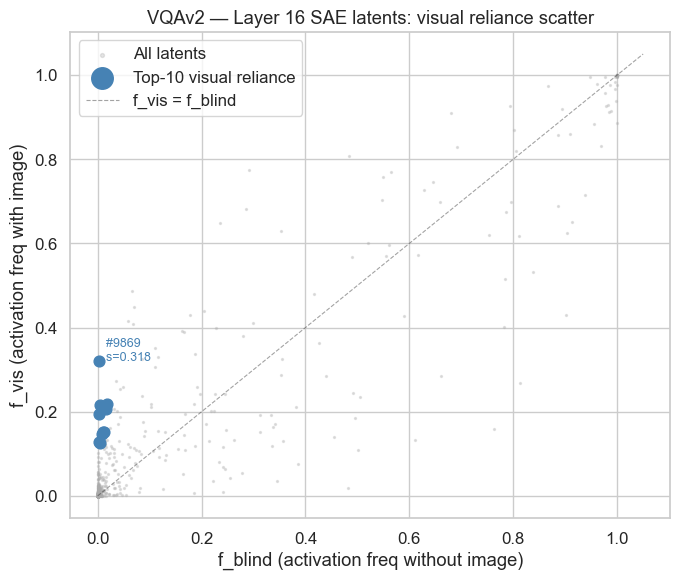

In [125]:
# Scatter: f_vis vs f_blind for all latents (VQAv2)
top_idx = [v['latent_idx'] for v in top_visual[:10]]
top0 = top_visual[0]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(f_blind_all, f_vis_all, s=2, alpha=0.3, color='#aaaaaa', label='All latents')
ax.scatter(f_blind_all[top_idx], f_vis_all[top_idx], s=60, color='steelblue',
           zorder=5, label='Top-10 visual reliance')
ax.annotate(f"  #{top0['latent_idx']}\n  s={top0['s_visual']:.3f}",
            xy=(top0['f_blind'], top0['f_vis']), fontsize=9, color='steelblue')
lim = max(f_vis_all.max(), f_blind_all.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4, label='f_vis = f_blind')
ax.set_xlabel('f_blind (activation freq without image)')
ax.set_ylabel('f_vis (activation freq with image)')
ax.set_title('VQAv2 — Layer 16 SAE latents: visual reliance scatter')
ax.legend(markerscale=2)
plt.tight_layout()
fs_vqav2_fig_dir = RESULTS / 'feature_search' / MODEL / 'vqav2' / 'figures'
fs_vqav2_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fs_vqav2_fig_dir / 'vqav2_scatter_fvis_fblind_layer16.png', dpi=150)
plt.show()

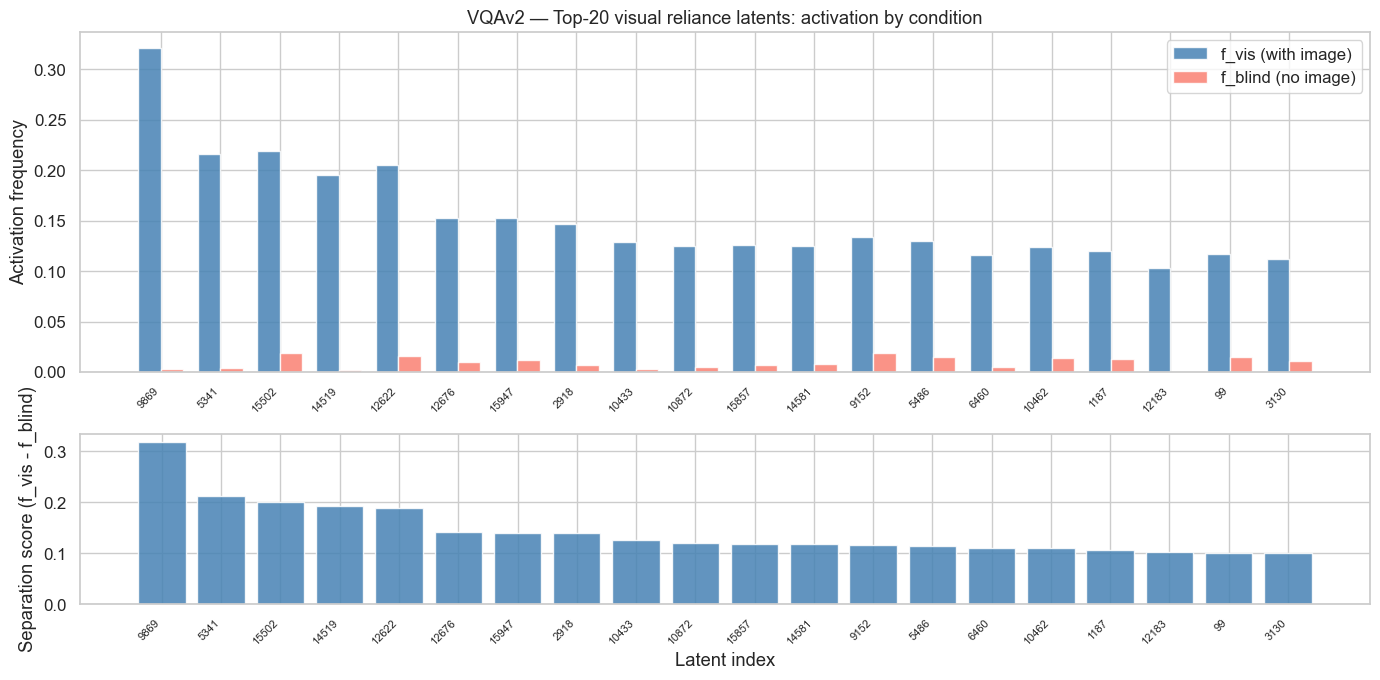

In [126]:
# Bar chart: top-20 visual reliance latents (VQAv2)
n_show = 20
feats  = top_visual[:n_show]
labels = [str(v['latent_idx']) for v in feats]
fv     = [v['f_vis']    for v in feats]
fb     = [v['f_blind']  for v in feats]
sv     = [v['s_visual'] for v in feats]
x      = np.arange(n_show)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={'height_ratios': [2, 1]})
w = 0.38
axes[0].bar(x - w/2, fv, w, label='f_vis (with image)', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, fb, w, label='f_blind (no image)', color='salmon',    alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Activation frequency')
axes[0].set_title('VQAv2 — Top-20 visual reliance latents: activation by condition')
axes[0].legend()

axes[1].bar(x, sv, color='steelblue', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Separation score (f_vis - f_blind)')
axes[1].set_xlabel('Latent index')
plt.tight_layout()
fs_vqav2_fig_dir = RESULTS / 'feature_search' / MODEL / 'vqav2' / 'figures'
fs_vqav2_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fs_vqav2_fig_dir / 'vqav2_top_visual_latents_layer16.png', dpi=150)
plt.show()

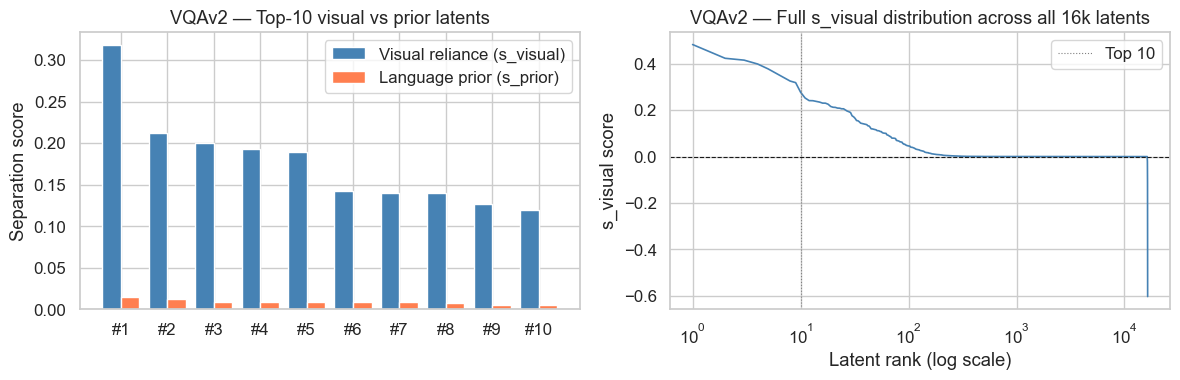

Latents with s_visual > 0.1:  60
Latents with s_visual > 0.05: 94
Clean top-50 (f_blind < 0.005): 23


In [127]:
# VQAv2: visual vs prior score comparison + full s_visual distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n = 10
vis_scores   = [v['s_visual'] for v in top_visual[:n]]
prior_scores = [v['s_prior']  for v in top_prior[:n]]
xi = np.arange(n)
axes[0].bar(xi - 0.2, vis_scores,   0.4, label='Visual reliance (s_visual)', color='steelblue')
axes[0].bar(xi + 0.2, prior_scores, 0.4, label='Language prior (s_prior)',   color='coral')
axes[0].set_xticks(xi)
axes[0].set_xticklabels([f'#{i+1}' for i in xi])
axes[0].set_ylabel('Separation score')
axes[0].set_title('VQAv2 — Top-10 visual vs prior latents')
axes[0].legend()

s_sorted = np.sort(s_vis_all)[::-1]
axes[1].plot(np.arange(1, len(s_sorted)+1), s_sorted, color='steelblue', lw=1.2)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].axvline(10, color='grey', lw=0.8, ls=':', label='Top 10')
axes[1].set_xscale('log')
axes[1].set_xlabel('Latent rank (log scale)')
axes[1].set_ylabel('s_visual score')
axes[1].set_title('VQAv2 — Full s_visual distribution across all 16k latents')
axes[1].legend()
plt.tight_layout()
fs_vqav2_fig_dir = RESULTS / 'feature_search' / MODEL / 'vqav2' / 'figures'
fs_vqav2_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fs_vqav2_fig_dir / 'vqav2_visual_prior_comparison_layer16.png', dpi=150)
plt.show()

print(f"Latents with s_visual > 0.1:  {(s_vis_all > 0.1).sum()}")
print(f"Latents with s_visual > 0.05: {(s_vis_all > 0.05).sum()}")
n_clean = sum(1 for v in top_visual[:50] if v['f_blind'] < 0.005)
print(f"Clean top-50 (f_blind < 0.005): {n_clean}")

### 3c. Feature Search on VAB — Comparison with VQAv2

Running the same contrastive search on VAB samples reveals a striking finding:
the top visual reliance latents are **almost entirely different** between datasets.

- Only 2 latents overlap in the top-20 (#6460, #15857)
- None of VQAv2's top-10 appear even in VAB's top-50
- VAB visual latents are even cleaner: top-8 have f_blind=0.000 exactly

**Interpretation:** VQAv2 latents encode *generic visual processing* (any image activates them).
VAB latents encode something more specific to VAB-type images (flags, logos, chess, anatomy).
The language prior signal remains weak on VAB (top s_prior=0.019) — bias likely operates through
suppression of visual latents, not activation of dedicated prior latents.

In [128]:
# Load VAB feature search results
fs_vab_dir = RESULTS / 'feature_search' / MODEL / 'vab' / 'layer_16'
with open(fs_vab_dir / 'summary.json') as f:
    fs_vab_summary = json.load(f)
with open(fs_vab_dir / 'top_features.json') as f:
    fs_vab_features = json.load(f)
fs_vab_scores = np.load(fs_vab_dir / 'scores.npz', allow_pickle=True)

top_visual_vab = fs_vab_features['top_visual']
top_prior_vab  = fs_vab_features['top_prior']
f_vis_vab   = fs_vab_scores['f_vis']
f_blind_vab = fs_vab_scores['f_blind']

# Overlap analysis
vqav2_top20 = {v['latent_idx'] for v in top_visual[:20]}
vab_top20   = {v['latent_idx'] for v in top_visual_vab[:20]}
vqav2_top10 = {v['latent_idx'] for v in top_visual[:10]}
vab_top50   = {v['latent_idx'] for v in top_visual_vab[:50]}

print(f"VQAv2 top-20 ∩ VAB top-20: {sorted(vqav2_top20 & vab_top20)}")
print(f"VQAv2 top-10 found in VAB top-50: {sorted(vqav2_top10 & vab_top50)}")
print()
print(f"VAB   top visual: #{fs_vab_summary['top_visual_latent']}  s={fs_vab_summary['top_visual_score']:.3f}")
print(f"VQAv2 top visual: #{fs_summary['top_visual_latent']}  s={fs_summary['top_visual_score']:.3f}")
print(f"VAB   top prior:  #{fs_vab_summary['top_prior_latent']}  s={fs_vab_summary['top_prior_score']:.4f}")
print(f"VQAv2 top prior:  #{fs_summary['top_prior_latent']}  s={fs_summary['top_prior_score']:.4f}")

VQAv2 top-20 ∩ VAB top-20: [6460, 15857]
VQAv2 top-10 found in VAB top-50: []

VAB   top visual: #12002  s=0.338
VQAv2 top visual: #9869  s=0.318
VAB   top prior:  #16186  s=0.0194
VQAv2 top prior:  #5303  s=0.0150


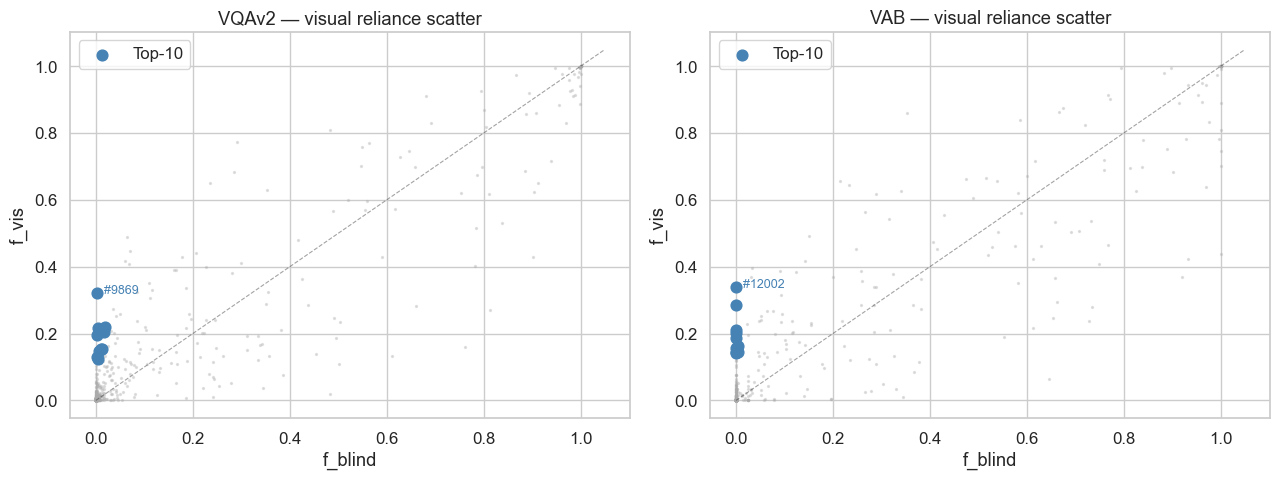

In [129]:
# Side-by-side scatter: VQAv2 vs VAB
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (f_v, f_b, tv, label) in zip(axes, [
    (f_vis_all,   f_blind_all, top_visual,     'VQAv2'),
    (f_vis_vab,   f_blind_vab, top_visual_vab, 'VAB'),
]):
    top_idx = [v['latent_idx'] for v in tv[:10]]
    ax.scatter(f_b, f_v, s=2, alpha=0.3, color='#aaaaaa')
    ax.scatter(f_b[top_idx], f_v[top_idx], s=60, color='steelblue', zorder=5, label='Top-10')
    top0 = tv[0]
    ax.annotate(f"  #{top0['latent_idx']}", xy=(top0['f_blind'], top0['f_vis']),
                fontsize=9, color='steelblue')
    lim = max(f_v.max(), f_b.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)
    ax.set_xlabel('f_blind'); ax.set_ylabel('f_vis')
    ax.set_title(f'{label} — visual reliance scatter')
    ax.legend()

plt.tight_layout()
fs_cmp_fig_dir = RESULTS / 'feature_search' / MODEL / 'comparison_vqav2_vs_vab' / 'figures'
fs_cmp_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fs_cmp_fig_dir / 'comparison_scatter_vqav2_vs_vab_layer16.png', dpi=150)
plt.show()

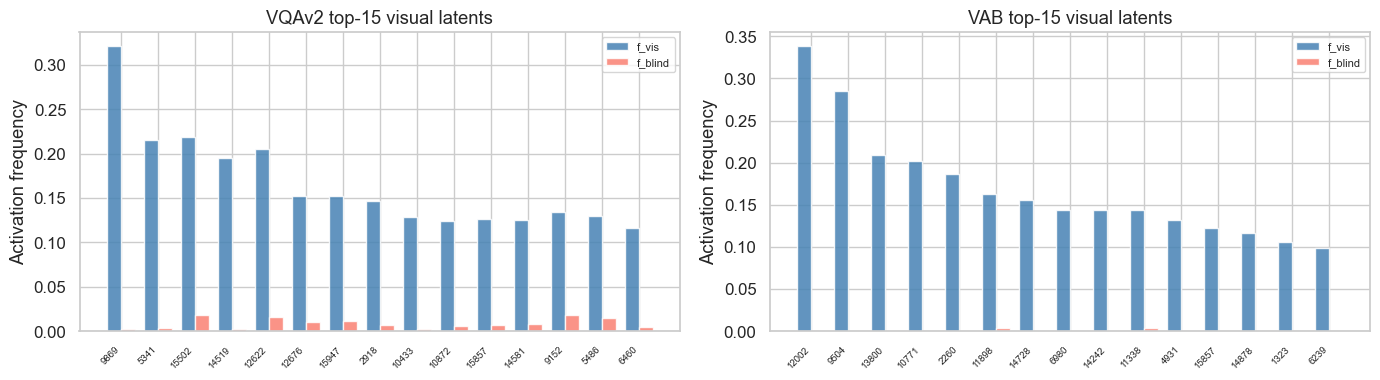

Shared latents in top-20: [6460, 15857]
VAB clean latents (f_blind=0.000): 18/20
VQAv2 clean latents (f_blind=0.000): 1/20


In [130]:
# Top-15 latents side by side: VQAv2 vs VAB
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (tv, label, scores_arr) in zip(axes, [
    (top_visual,     'VQAv2', f_vis_all),
    (top_visual_vab, 'VAB',   f_vis_vab),
]):
    n = 15
    feats = tv[:n]
    x = np.arange(n)
    fv = [v['f_vis']    for v in feats]
    fb = [v['f_blind']  for v in feats]
    sv = [v['s_visual'] for v in feats]
    labels = [str(v['latent_idx']) for v in feats]
    w = 0.38
    ax.bar(x - w/2, fv, w, label='f_vis',   color='steelblue', alpha=0.85)
    ax.bar(x + w/2, fb, w, label='f_blind', color='salmon',    alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Activation frequency'); ax.set_title(f'{label} top-15 visual latents')
    ax.legend(fontsize=8)

plt.tight_layout()
fs_cmp_fig_dir = RESULTS / 'feature_search' / MODEL / 'comparison_vqav2_vs_vab' / 'figures'
fs_cmp_fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fs_cmp_fig_dir / 'comparison_top_latents_vqav2_vs_vab_layer16.png', dpi=150)
plt.show()

# Overlap summary
shared = sorted(vqav2_top20 & vab_top20)
print(f"Shared latents in top-20: {shared if shared else 'None'}")
print(f"VAB clean latents (f_blind=0.000): {sum(1 for v in top_visual_vab[:20] if v['f_blind'] == 0.0)}/20")
print(f"VQAv2 clean latents (f_blind=0.000): {sum(1 for v in top_visual[:20] if v['f_blind'] == 0.0)}/20")

## 4. REVIS Steering

REVIS (arXiv:2602.11824): computes a purified visual steering vector at layer 16 via
Gram-Schmidt orthogonalization against the language prior direction, then adds
`α × v_pure` to the residual stream during generation.

- **Negative α** pushes against the computed visual direction (empirically helps here)
- **Positive α** amplifies it (hurts — possibly the VQAv2 calibration data misaligns the vector)

Results load automatically for all datasets present in `results/revis/`.

In [131]:
import glob as _glob

revis_dir = RESULTS / 'revis'
revis_data = {}  # dataset -> list of (alpha, vanilla_acc, steered_acc, delta, fixed, broke, n)

for ds_dir in sorted(revis_dir.iterdir()):
    if not ds_dir.is_dir():
        continue
    ds = ds_dir.name
    rows = []
    for f in sorted(ds_dir.glob('revis_layer16_alpha*.jsonl')):
        records = [json.loads(l) for l in open(f)]
        if not records or 'is_correct_steered' not in records[0]:
            continue
        n = len(records)
        alpha = records[0]['alpha']
        acc_s = sum(r['is_correct_steered'] for r in records) / n
        acc_v = sum(r['is_correct_vanilla'] for r in records) / n
        fixed = sum(1 for r in records if not r['is_correct_vanilla'] and r['is_correct_steered'])
        broke = sum(1 for r in records if r['is_correct_vanilla'] and not r['is_correct_steered'])
        rows.append((alpha, acc_v, acc_s, acc_s - acc_v, fixed, broke, n))
    if rows:
        revis_data[ds] = sorted(rows)

print(f"Datasets with REVIS results: {list(revis_data.keys())}")
for ds, rows in revis_data.items():
    vanilla = next((r[1] for r in rows if r[0] == 0.0), rows[0][1])
    best = max(rows, key=lambda r: r[3])
    print(f"  {ds:8s}  vanilla={vanilla:.3f}  best_α={best[0]:+.0f}  "
          f"steered={best[2]:.3f}  Δ={best[3]:+.3f}  fixed={best[4]}  broke={best[5]}")

Datasets with REVIS results: ['vab', 'vilp', 'vlind']
  vab       vanilla=0.000  best_α=-200  steered=0.000  Δ=+0.000  fixed=0  broke=0
  vilp      vanilla=0.723  best_α=-200  steered=0.747  Δ=+0.023  fixed=7  broke=0
  vlind     vanilla=0.099  best_α=-200  steered=0.202  Δ=+0.103  fixed=23  broke=0


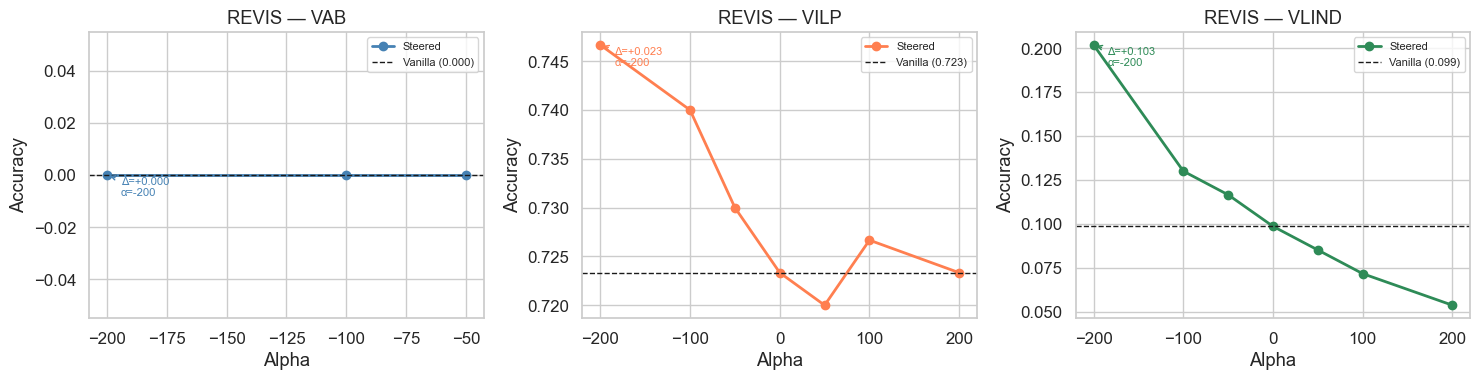

In [132]:
# REVIS: accuracy vs alpha curves, one panel per dataset
n_ds = len(revis_data)
if n_ds == 0:
    print("No REVIS results yet.")
else:
    fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4), sharey=False)
    if n_ds == 1:
        axes = [axes]

    colors = {'vab': 'steelblue', 'vilp': 'coral', 'vlind': 'seagreen', 'vqav2': 'purple'}

    for ax, (ds, rows) in zip(axes, revis_data.items()):
        alphas  = [r[0] for r in rows]
        steered = [r[2] for r in rows]
        vanilla = rows[0][1]
        color   = colors.get(ds, 'grey')

        ax.plot(alphas, steered, 'o-', color=color, lw=2, label='Steered')
        ax.axhline(vanilla, color='k', ls='--', lw=1, label=f'Vanilla ({vanilla:.3f})')
        ax.set_xlabel('Alpha'); ax.set_ylabel('Accuracy')
        ax.set_title(f'REVIS — {ds.upper()}')
        ax.legend(fontsize=8)

        best = max(rows, key=lambda r: r[3])
        ax.annotate(f"Δ={best[3]:+.3f}\nα={best[0]:+.0f}",
                    xy=(best[0], best[2]),
                    xytext=(10, -15), textcoords='offset points',
                    fontsize=8, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1))

    plt.tight_layout()
    plt.savefig(RESULTS / 'revis' / 'revis_accuracy_curves.png', dpi=150)
    plt.show()

In [133]:
# REVIS summary table
print(f"{'Dataset':>8}  {'N':>5}  {'Vanilla':>8}  {'Best α':>7}  {'Steered':>8}  {'Δ':>7}  {'Fixed':>6}  {'Broke':>6}")
print('-' * 72)
for ds, rows in revis_data.items():
    vanilla = next((r[1] for r in rows if r[0] == 0.0), rows[0][1])
    best = max(rows, key=lambda r: r[3])
    print(f"{ds:>8}  {best[6]:>5}  {vanilla:>8.3f}  {best[0]:>+7.0f}  "
          f"{best[2]:>8.3f}  {best[3]:>+7.3f}  {best[4]:>6}  {best[5]:>6}")

 Dataset      N   Vanilla   Best α   Steered        Δ   Fixed   Broke
------------------------------------------------------------------------
     vab   2784     0.000     -200     0.000   +0.000       0       0
    vilp    300     0.723     -200     0.747   +0.023       7       0
   vlind    223     0.099     -200     0.202   +0.103      23       0


## 5. SAE Causal Steering (Exp 3.3)

Steers using GemmaScope SAE decoder directions `W_dec[j]` at layer 16.
Top-5 latents from the VQAv2 contrastive search (#9869, #5341, #15502, #14519, #12622).

Key comparison vs REVIS:
- **ViLP:** SAE best +6.0% (#5341, α=+500) vs REVIS +2.3% → **SAE wins**
- **VLind:** SAE best +6.0% (#14519, α=−500) vs REVIS +10.3% → **REVIS wins**

Results load automatically for all datasets present in `results/steering/`.

In [141]:
steering_dir = RESULTS / 'steering' / MODEL
steering_data = {}  # dataset -> all_summaries list

for ds_dir in sorted(steering_dir.iterdir()):
    if not ds_dir.is_dir() or ds_dir.name.endswith('_old'):
        continue
    summary_path = ds_dir / 'layer_16' / 'all_summaries.json'
    if summary_path.exists():
        steering_data[ds_dir.name] = json.load(open(summary_path))

print(f"Datasets with steering results: {list(steering_data.keys())}")
for ds, summaries in steering_data.items():
    vanilla = next(r['vanilla_accuracy'] for r in summaries if r['alpha'] == 0.0)
    best = max(summaries, key=lambda r: r['delta'])
    print(f"  {ds:8s}  vanilla={vanilla:.3f}  "
          f"best: latent #{best['latent_idx']} α={best['alpha']:+.0f}  "
          f"steered={best['steered_accuracy']:.3f}  Δ={best['delta']:+.3f}")

Datasets with steering results: ['vab', 'vilp', 'vlind']
  vab       vanilla=0.173  best: latent #12002 α=+200  steered=0.174  Δ=+0.001
  vilp      vanilla=0.723  best: latent #5341 α=+500  steered=0.783  Δ=+0.060
  vlind     vanilla=0.106  best: latent #14519 α=-500  steered=0.166  Δ=+0.060


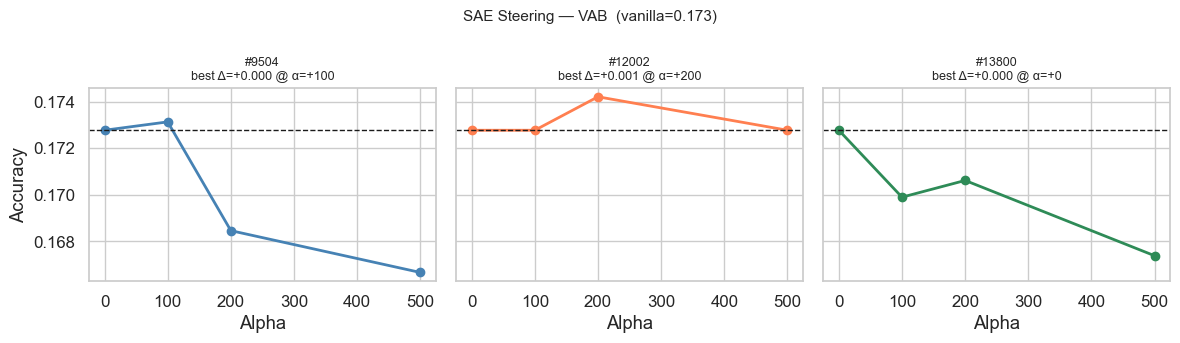

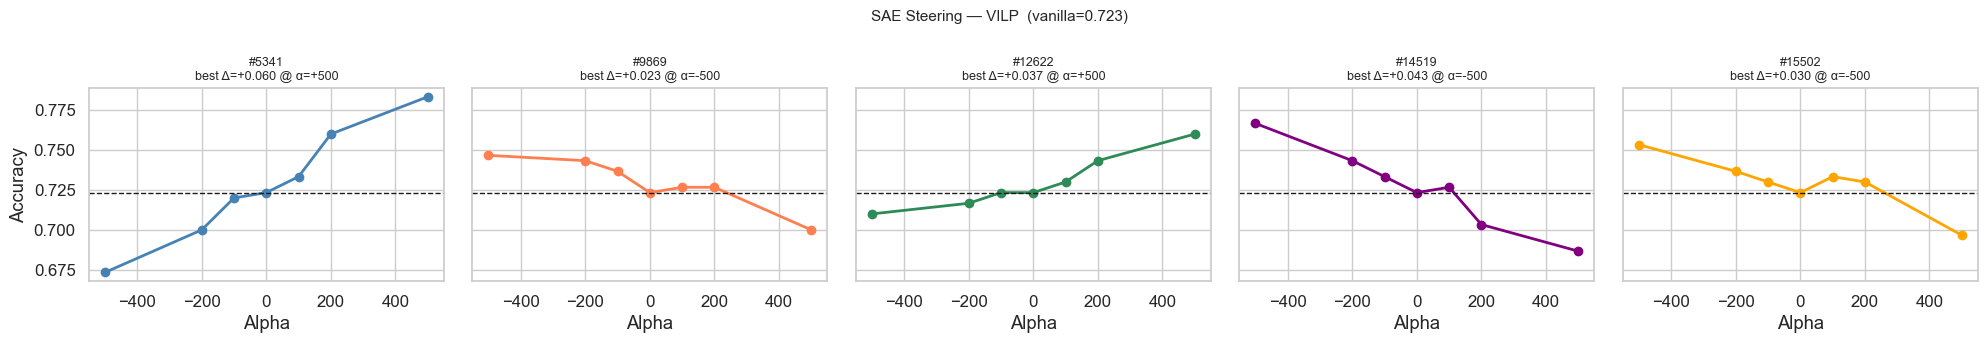

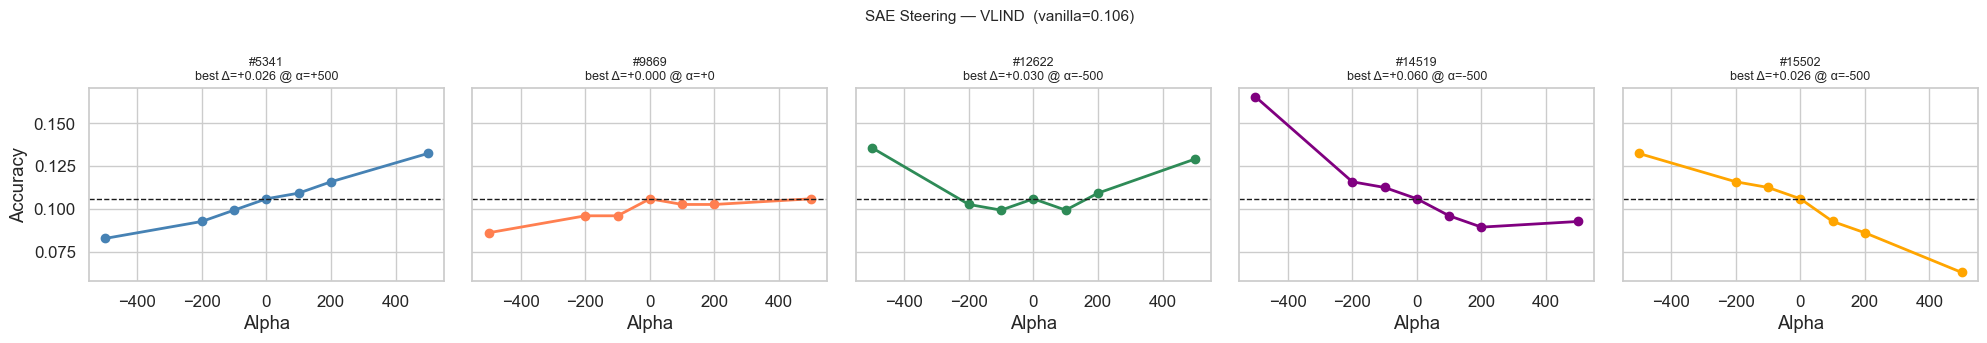

In [142]:
# SAE steering: per-latent alpha curves, one row per dataset
if not steering_data:
    print("No steering results yet.")
else:
    colors_latent = ['steelblue', 'coral', 'seagreen', 'purple', 'orange']

    for ds, summaries in steering_data.items():
        latent_ids = sorted({r['latent_idx'] for r in summaries})
        fig, axes = plt.subplots(1, len(latent_ids), figsize=(4 * len(latent_ids), 3.5), sharey=True)
        if len(latent_ids) == 1:
            axes = [axes]

        vanilla = next(r['vanilla_accuracy'] for r in summaries if r['alpha'] == 0.0)

        for ax, (lat, color) in zip(axes, zip(latent_ids, colors_latent)):
            runs = sorted([r for r in summaries if r['latent_idx'] == lat],
                          key=lambda r: r['alpha'])
            alphas  = [r['alpha'] for r in runs]
            steered = [r['steered_accuracy'] for r in runs]
            ax.plot(alphas, steered, 'o-', color=color, lw=2)
            ax.axhline(vanilla, color='k', ls='--', lw=1)
            best = max(runs, key=lambda r: r['delta'])
            ax.set_title(f'#{lat}\nbest Δ={best["delta"]:+.3f} @ α={best["alpha"]:+.0f}',
                         fontsize=9)
            ax.set_xlabel('Alpha')
            if ax == axes[0]:
                ax.set_ylabel('Accuracy')

        fig.suptitle(f'SAE Steering — {ds.upper()}  (vanilla={vanilla:.3f})', fontsize=11)
        plt.tight_layout()
        plt.savefig(RESULTS / 'steering' / f'steering_{ds}_curves.png', dpi=150)
        plt.show()

In [143]:
# SAE steering vs REVIS comparison table
print("Comparison: best SAE latent vs REVIS, per dataset")
print()
print(f"{'Dataset':>8}  {'Vanilla':>8}  {'SAE best Δ':>11}  {'SAE latent':>11}  {'REVIS best Δ':>13}  {'REVIS α':>8}  {'Winner':>8}")
print('-' * 80)

all_ds = sorted(set(list(steering_data.keys()) + list(revis_data.keys())))
for ds in all_ds:
    vanilla = None
    sae_str, revis_str, winner = 'N/A', 'N/A', '—'

    if ds in steering_data:
        summaries = steering_data[ds]
        vanilla = next((r['vanilla_accuracy'] for r in summaries if r['alpha'] == 0.0), None)
        best_sae = max(summaries, key=lambda r: r['delta'])
        sae_str = f"{best_sae['delta']:+.3f}"
        lat_str = f"#{best_sae['latent_idx']}"

    if ds in revis_data:
        rows = revis_data[ds]
        if vanilla is None:
            vanilla = next((r[1] for r in rows if r[0] == 0.0), rows[0][1])
        best_revis = max(rows, key=lambda r: r[3])
        revis_str = f"{best_revis[3]:+.3f}"
        revis_a   = f"{best_revis[0]:+.0f}"

        if ds in steering_data:
            best_sae_d = max(steering_data[ds], key=lambda r: r['delta'])['delta']
            winner = 'SAE' if best_sae_d > best_revis[3] else 'REVIS'
    else:
        revis_a = '—'

    v_str = f"{vanilla:.3f}" if vanilla is not None else '—'
    lat_out = lat_str if ds in steering_data else '—'
    print(f"{ds:>8}  {v_str:>8}  {sae_str:>11}  {lat_out:>11}  {revis_str:>13}  {revis_a:>8}  {winner:>8}")

Comparison: best SAE latent vs REVIS, per dataset

 Dataset   Vanilla   SAE best Δ   SAE latent   REVIS best Δ   REVIS α    Winner
--------------------------------------------------------------------------------
     vab     0.173       +0.001       #12002         +0.000      -200       SAE
    vilp     0.723       +0.060        #5341         +0.023      -200       SAE
   vlind     0.106       +0.060       #14519         +0.103      -200     REVIS


## 4. WS3 Target Layer

In [137]:
print('=== WS3 Target Layer Summary ===')
print('\nVIP (Visual Integration Point — onset of visual influence):')
for ds in DATASETS:
    s = coe_summaries[ds]
    print(f'  {LABELS[ds]:<6}  median={s["vip_median"]}  mean={s["vip_mean"]:.1f}')

print('\nSAE Convergence (when visual tokens look like text features):')
print(f'  Reported layer (3-consecutive): {sae_summary["convergence_layer"]}')
print(f'  Minimum visual MSE layer:       {stable_min_layer}')

print('\nMechanistic story:')
print(f'  L{stable_min_layer}: visual tokens adopt LLM feature vocabulary (SAE convergence)')
print(f'  L15: last token first attends to those translated visual features (VIP)')
print(f'  L{peak}: visual correction has maximum impact on output distribution (EVA peak)')

print('\n→ WS3 target layer: 15  (run feature search at VIP first)')

=== WS3 Target Layer Summary ===

VIP (Visual Integration Point — onset of visual influence):
  VAB     median=16  mean=16.1
  ViLP    median=15  mean=15.3
  VLind   median=15  mean=14.9

SAE Convergence (when visual tokens look like text features):
  Reported layer (3-consecutive): 3
  Minimum visual MSE layer:       14

Mechanistic story:
  L14: visual tokens adopt LLM feature vocabulary (SAE convergence)
  L15: last token first attends to those translated visual features (VIP)
  L30: visual correction has maximum impact on output distribution (EVA peak)

→ WS3 target layer: 15  (run feature search at VIP first)


## 5. Key Findings

| Finding | Value | Interpretation |
|---|---|---|
| VIP (all benchmarks) | Layer 15–16 | Consistent onset across VAB, ViLP, VLind |
| SAE convergence | Layer 13 (min MSE) | Visual tokens adopt LLM feature space 2 layers before VIP |
| EVA peak layer | Layer 30 | Visual correction most effective deep in the network |
| VAB n_dvt | 0 / 2784 | Pending rerun — likely language prior completely dominates |
| VLind accuracy | 10.3% | Model ignores image even when instructed not to |
| ViLP EVA α=2.0 | −10 pp | Visual injection from L30 hurts — signal contaminated by LP |
| VLind EVA α=2.0 | +4 pp | EVA helps slightly — some visual signal recoverable |
| **WS3 target layer** | **15** | Intersection of VIP and SAE convergence region |

## 6. Concept Analysis — SAE Training Data vs. Bias Benchmarks

Uses CLIP ViT-L/14-336 Top-K concept assignment (LLaVA-OneVision style) to compare
what visual concepts appear in the bias benchmarks vs. ImageNet (SAE training data).

A concept vocabulary of 1204 terms is built from benchmark metadata
(VAB topics/sub_topics, VLind-Bench concept fields, ViLP answer words) plus
ImageNet class names. Each image is assigned its top-5 nearest concepts in
CLIP embedding space; concept frequencies are then compared across datasets.

In [138]:
ca_dir  = RESULTS / 'concept_analysis'
ca_freq = np.load(ca_dir / 'frequencies.npz', allow_pickle=True)
ca_concepts = list(ca_freq['concepts'])

with open(ca_dir / 'gap_analysis.json') as f:
    ca_gap = json.load(f)

gap_key = 'benchmarks_vs_imagenet'
gap     = ca_gap[gap_key]

print(f'Vocabulary size: {len(ca_concepts)} concepts')
print(f'Datasets:        {[k for k in ca_freq.keys() if k != "concepts"]}')
print(f'KL(benchmarks || ImageNet): {gap["kl_divergence"]:.3f}')
print()
print(f"{'Concept':<32} {'Benchmark':>10} {'ImageNet':>10} {'Gap':>10}")
print('-' * 66)
for item in gap['over_represented'][:20]:
    print(f"{item['concept']:<32} {item['benchmark_freq']:>10.4f} "
          f"{item['training_freq']:>10.4f} {item['gap']:>+10.4f}")

Vocabulary size: 1204 concepts
Datasets:        ['vab', 'vilp', 'vlind_bench', 'imagenet']
KL(benchmarks || ImageNet): 1.291

Concept                           Benchmark   ImageNet        Gap
------------------------------------------------------------------
tally pattern                        0.0239     0.0022    +0.0217
ebbinghaus illusion                  0.0220     0.0005    +0.0215
go grid                              0.0184     0.0011    +0.0173
xiangqi grid                         0.0162     0.0004    +0.0158
poggendorff illusion                 0.0118     0.0008    +0.0109
vertical-horizontal illusion         0.0111     0.0010    +0.0100
game boards                          0.0107     0.0010    +0.0097
sudoku grid                          0.0102     0.0007    +0.0095
climate                              0.0095     0.0004    +0.0092
chess grid                           0.0084     0.0003    +0.0081
animal add legs                      0.0085     0.0010    +0.0075
time           

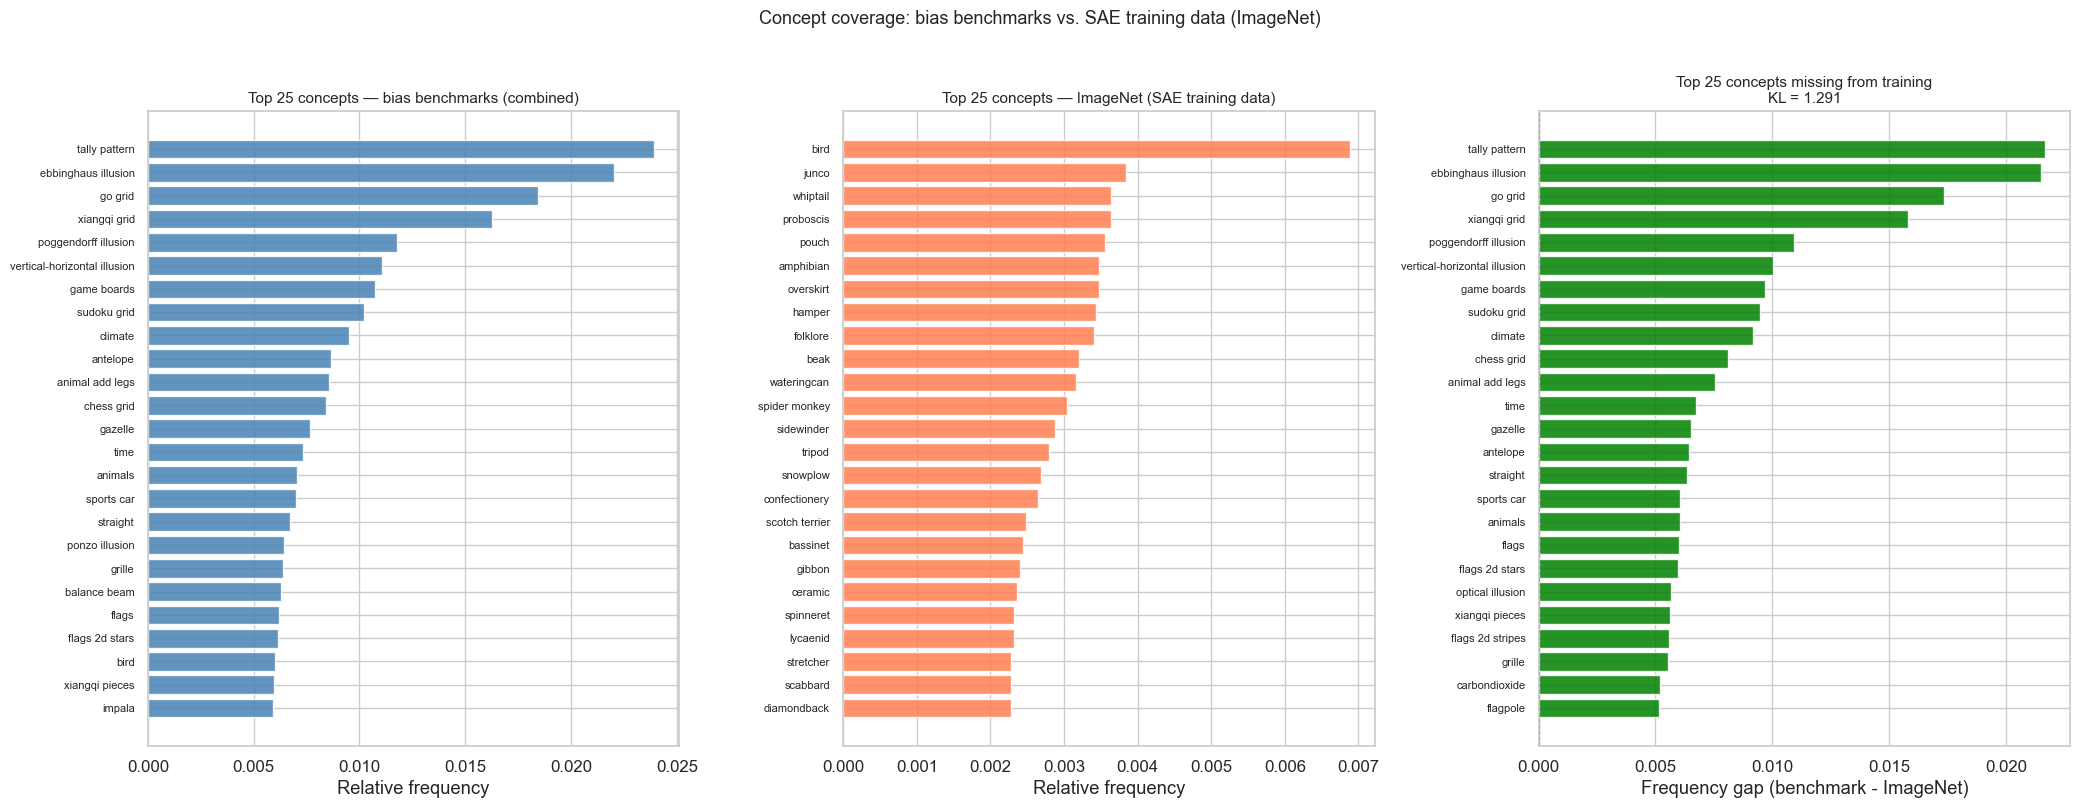

In [139]:
bench_keys  = ['vab', 'vilp', 'vlind_bench']
bench_freq  = np.mean([ca_freq[k] for k in bench_keys], axis=0)
train_freq  = ca_freq['imagenet']
gap_scores  = np.array(gap['gap_scores'])
top_n = 25

fig, axes = plt.subplots(1, 3, figsize=(21, 8))

# Panel 1 — top benchmark concepts
ax = axes[0]
idx = np.argsort(bench_freq)[-top_n:][::-1]
ax.barh([ca_concepts[i][:35] for i in idx[::-1]], bench_freq[idx[::-1]], color='steelblue', alpha=0.85)
ax.set_xlabel('Relative frequency')
ax.set_title(f'Top {top_n} concepts — bias benchmarks (combined)', fontsize=11)
ax.tick_params(axis='y', labelsize=8)

# Panel 2 — top ImageNet concepts
ax = axes[1]
idx = np.argsort(train_freq)[-top_n:][::-1]
ax.barh([ca_concepts[i][:35] for i in idx[::-1]], train_freq[idx[::-1]], color='coral', alpha=0.85)
ax.set_xlabel('Relative frequency')
ax.set_title(f'Top {top_n} concepts — ImageNet (SAE training data)', fontsize=11)
ax.tick_params(axis='y', labelsize=8)

# Panel 3 — gap (concepts missing from training)
ax = axes[2]
gap_items = gap['over_represented'][:top_n]
ax.barh([d['concept'][:35] for d in gap_items[::-1]], [d['gap'] for d in gap_items[::-1]],
        color='green', alpha=0.85)
ax.set_xlabel('Frequency gap (benchmark - ImageNet)')
ax.set_title(f'Top {top_n} concepts missing from training\nKL = {gap["kl_divergence"]:.3f}', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
ax.axvline(0, color='black', lw=0.8, linestyle='--')

plt.suptitle('Concept coverage: bias benchmarks vs. SAE training data (ImageNet)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ca_dir / 'figures' / 'comparison_nb.png', dpi=150, bbox_inches='tight')
plt.show()

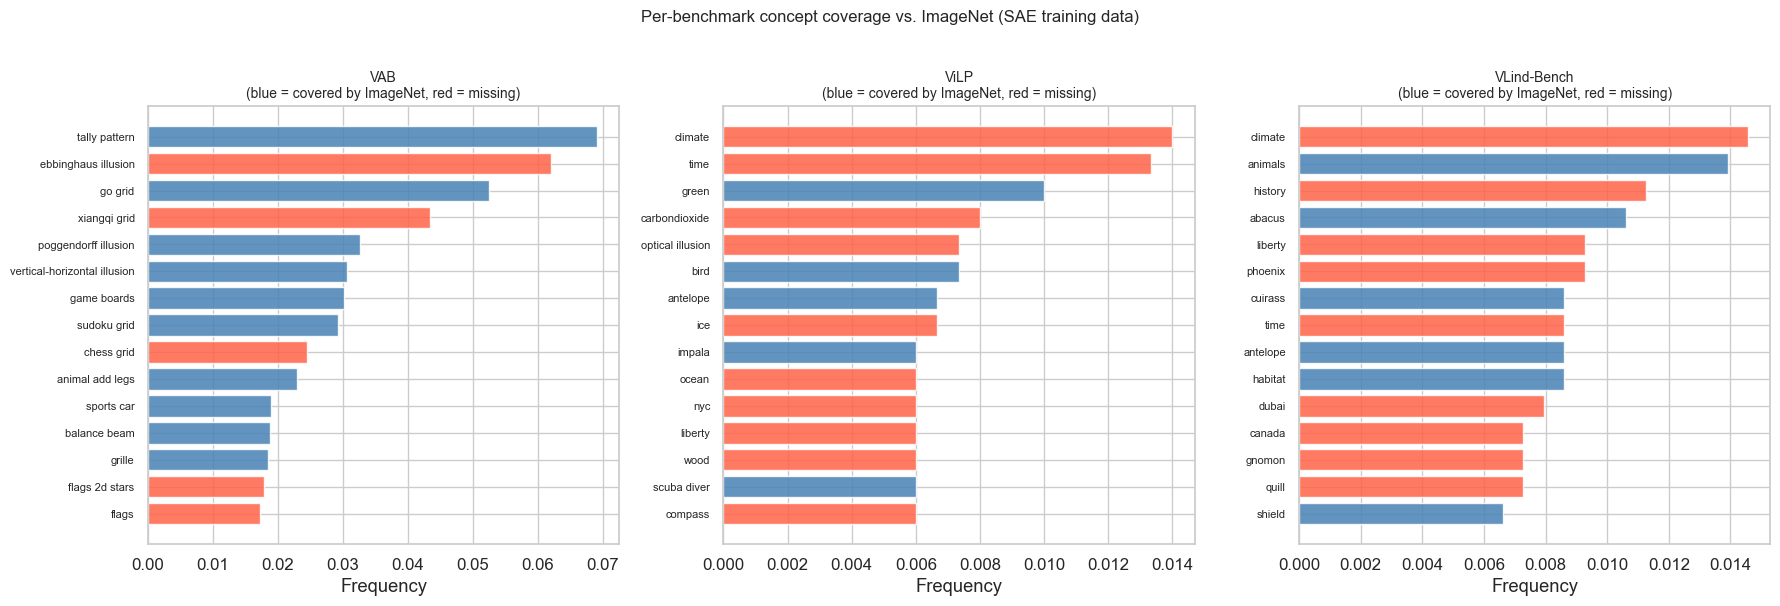

Benchmark        Active concepts   Covered by IN   Coverage %
------------------------------------------------------------
VAB                          247             139        56.3%
ViLP                         575             274        47.7%
VLind-Bench                  587             301        51.3%


In [140]:
bench_info = {
    'vab':         ('VAB',         'steelblue'),
    'vilp':        ('ViLP',        'coral'),
    'vlind_bench': ('VLind-Bench', 'seagreen'),
}
threshold = np.median(train_freq[train_freq > 0])
top_n = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (bk, (label, color)) in zip(axes, bench_info.items()):
    freq = ca_freq[bk]
    idx  = np.argsort(freq)[-top_n:][::-1]
    covered = [train_freq[i] >= threshold for i in idx[::-1]]
    ax.barh(
        [ca_concepts[i][:30] for i in idx[::-1]],
        freq[idx[::-1]],
        color=['steelblue' if c else 'tomato' for c in covered],
        alpha=0.85,
    )
    ax.set_xlabel('Frequency')
    ax.set_title(f'{label}\n(blue = covered by ImageNet, red = missing)', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Per-benchmark concept coverage vs. ImageNet (SAE training data)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(ca_dir / 'figures' / 'per_benchmark_nb.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Benchmark':<15} {'Active concepts':>16} {'Covered by IN':>15} {'Coverage %':>12}")
print('-' * 60)
for bk, (label, _) in bench_info.items():
    freq    = ca_freq[bk]
    active  = freq > 0
    covered = (train_freq >= threshold) & active
    pct     = 100 * covered.sum() / active.sum() if active.sum() > 0 else 0
    print(f'{label:<15} {active.sum():>16} {covered.sum():>15} {pct:>11.1f}%')